In [ ]:
# prompt: import necessary librarires for data frame and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# prompt: import dataset

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Estimator Data/ESTIMATION_HISTORY (1)(in).csv')
# Columns to encode
columns_to_encode = ['E_CUSTOMIZATION_LEVEL', 'E_DEAL_CONSTRUCT',
                     'E_EXPERIENCED', 'E_DELIVERY_METHEDOLOGY']

# Label encode each column before any numeric coercion
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in columns_to_encode:
    if col in df.columns:
        df[col] = df[col].astype(str).fillna("Missing")
        df[col] = le.fit_transform(df[col])

<Figure size 1200x1000 with 0 Axes>

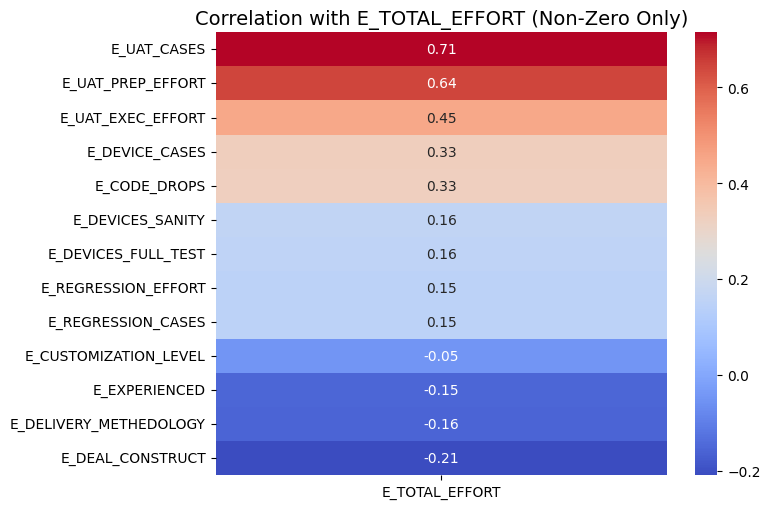

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Remove commas from all object columns and convert to numeric
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop non-numeric or irrelevant columns
df_cleaned = df.drop(columns=['E_EST_NAME', 'E_EST_DATE_TIME1'], errors='ignore')

# Compute correlation matrix
correlation_matrix = df_cleaned.corr()

# Extract correlation with target column
target_corr = correlation_matrix['E_TOTAL_EFFORT'].drop('E_TOTAL_EFFORT')  # exclude self-correlation

# Filter out zero or NaN correlations
target_corr_nonzero = target_corr[abs(target_corr) > 0].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, max(1, len(target_corr_nonzero) * 0.4)))  # dynamic height based on number of entries
sns.heatmap(target_corr_nonzero.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

plt.title('Correlation with E_TOTAL_EFFORT (Non-Zero Only)', fontsize=14)
plt.tight_layout()
plt.show()



Selected features with non-zero correlation with E_TOTAL_EFFORT:
['E_EST_NAME', 'E_EST_DATE_TIME1', 'E_UAT_PREP_EFFORT', 'E_UAT_EXEC_EFFORT', 'E_REGRESSION_EFFORT', 'E_CLIENT_TYPE', 'E_CUSTOMIZATION_LEVEL', 'E_DEAL_CONSTRUCT', 'E_PROJECT_DOMAIN', 'E_EXPERIENCED', 'E_UAT_CASES', 'E_REGRESSION_CASES', 'E_DEVICES_FULL_TEST', 'E_DEVICE_CASES', 'E_DEVICES_SANITY', 'E_UPDATED_BY', 'E_CODE_DROPS', 'E_DELIVERY_METHEDOLOGY', 'E_EST_DATE_TIME']

Model Evaluation Metrics:
MAE (Mean Absolute Error): 12.57
MSE (Mean Squared Error): 3427.00
R² Score: 0.76


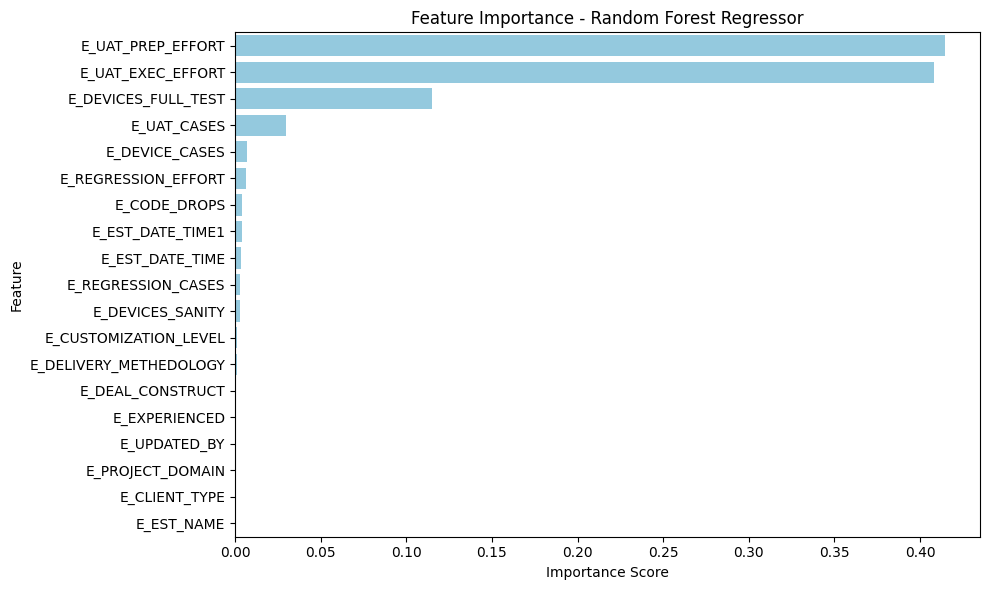

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Estimator Data/ESTIMATION_HISTORY (1)(in).csv')  # Change to your dataset file

# Step 2: Identify categorical columns (object or category)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 3: Label Encode categorical columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str).fillna("Missing")
    df[col] = le.fit_transform(df[col])

# Step 4: Drop any remaining non-numeric columns (if any slipped through)
df_numeric = df.select_dtypes(include=[np.number])

# Step 5: Drop rows where E_TOTAL_EFFORT is missing
df_numeric = df_numeric.dropna(subset=['E_TOTAL_EFFORT'])

# Step 6: Compute correlation with target
correlation_matrix = df_numeric.corr()
target_corr = correlation_matrix['E_TOTAL_EFFORT'].drop('E_TOTAL_EFFORT')

# Step 7: Select features with non-zero correlation
non_zero_corr_features = target_corr[abs(target_corr) > 0].index.tolist()

print("\nSelected features with non-zero correlation with E_TOTAL_EFFORT:")
print(non_zero_corr_features)

# Step 8: Define features and label
X = df_numeric[non_zero_corr_features]
y = df_numeric['E_TOTAL_EFFORT']

# Optional: fill missing values
X = X.fillna(X.mean())

# Step 9: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 10: Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 11: Predictions
y_pred = rf.predict(X_test)

# Step 12: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Step 13: Feature Importance Plot
importances = rf.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index, color='skyblue')

plt.title('Feature Importance - Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
#Try GridSearch for better accuracy:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)


Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Final model with best params
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

# Train on full training data
rf_final.fit(X_train, y_train)

# Predict
y_pred_final = rf_final.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_final)
mse = mean_squared_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)

print("\n🔍 Final Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")



🔍 Final Model Evaluation:
MAE: 12.96
MSE: 3431.49
R² Score: 0.76


XGBoost Pipeline for Effort Prediction


✅ Selected Features:
['E_EST_NAME', 'E_UAT_PREP_EFFORT', 'E_UAT_EXEC_EFFORT', 'E_REGRESSION_EFFORT', 'E_CLIENT_TYPE', 'E_CUSTOMIZATION_LEVEL', 'E_DEAL_CONSTRUCT', 'E_PROJECT_DOMAIN', 'E_EXPERIENCED', 'E_UAT_CASES', 'E_REGRESSION_CASES', 'E_DEVICES_FULL_TEST', 'E_DEVICE_CASES', 'E_DEVICES_SANITY', 'E_UPDATED_BY', 'E_CODE_DROPS', 'E_DELIVERY_METHEDOLOGY', 'E_EST_DATE_TIME']

🔍 XGBoost Model Evaluation:
MAE: 10.83
MSE: 1963.18
R² Score: 0.86

📊 Cross-Validated R² Scores: [0.80707764 0.92356263 0.59891217 0.77985213 0.79254786]
Average CV R²: 0.78


/tmp/ipython-input-2-1098778548.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index, palette='coolwarm')


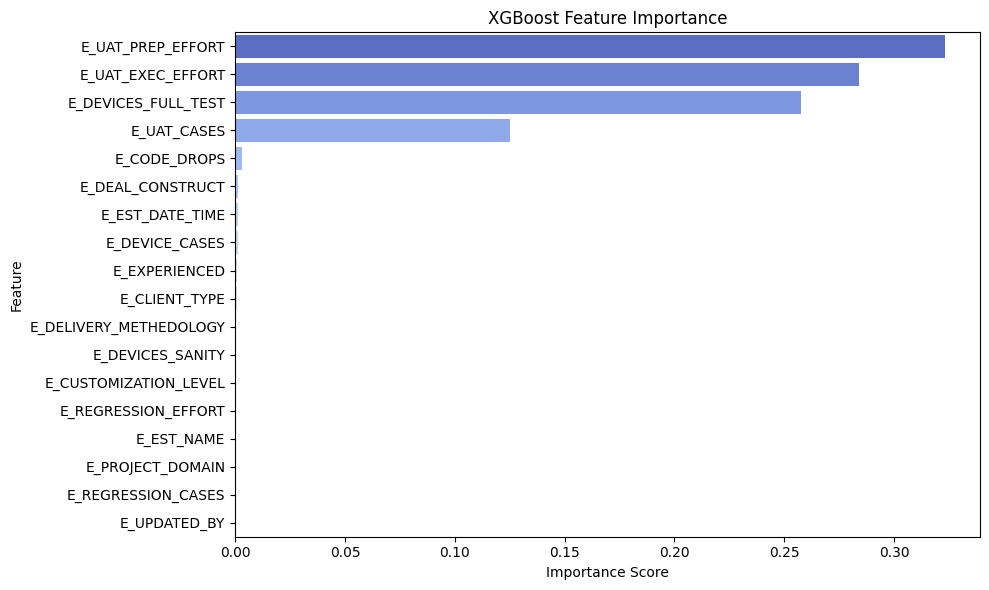

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load and inspect data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Estimator Data/ESTIMATION_HISTORY (1)(in).csv")  # Change this to your actual file

# Step 2: Encode categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str).fillna("Missing")
    df[col] = le.fit_transform(df[col])

# Step 3: Handle datetime features (optional but useful)
if 'E_EST_DATE_TIME1' in df.columns:
    df['E_EST_DATE_TIME1'] = pd.to_datetime(df['E_EST_DATE_TIME1'], errors='coerce')
    df['E_EST_MONTH'] = df['E_EST_DATE_TIME1'].dt.month
    df['E_EST_DAYOFWEEK'] = df['E_EST_DATE_TIME1'].dt.dayofweek
    df.drop(columns=['E_EST_DATE_TIME1'], inplace=True)

# Step 4: Drop any remaining non-numeric or unneeded columns
df_numeric = df.select_dtypes(include=[np.number])
df_numeric = df_numeric.dropna(subset=['E_TOTAL_EFFORT'])

# Step 5: Feature selection by correlation
correlation_matrix = df_numeric.corr()
target_corr = correlation_matrix['E_TOTAL_EFFORT'].drop('E_TOTAL_EFFORT')
selected_features = target_corr[abs(target_corr) > 0].index.tolist()

print("\n✅ Selected Features:")
print(selected_features)

# Step 6: Prepare data
X = df_numeric[selected_features].fillna(df_numeric[selected_features].mean())
y = df_numeric['E_TOTAL_EFFORT']

# Step 7: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train XGBoost model
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# Step 9: Predict
y_pred = xgb.predict(X_test)

# Step 10: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n🔍 XGBoost Model Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Step 11: Cross-validation
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='r2')
print("\n📊 Cross-Validated R² Scores:", cv_scores)
print(f"Average CV R²: {np.mean(cv_scores):.2f}")

# Step 12: Feature Importance Plot
importances = xgb.feature_importances_
feat_imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index, palette='coolwarm')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



✅ XGBoost Model Evaluation (Native API):
MAE: 16.12
MSE: 1629.18
R² Score: 0.89


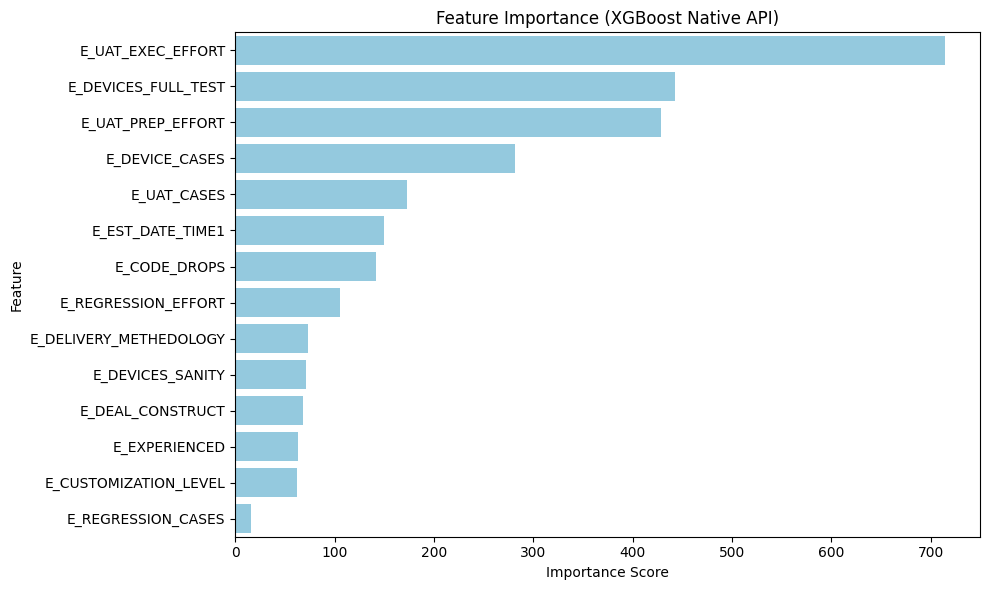

In [ ]:
# Re-import XGBoost to avoid name shadowing
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Upload and load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Estimator Data/ESTIMATION_HISTORY (1)(in).csv")  # Change this to your actual file


# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str).fillna("Missing")
    df[col] = le.fit_transform(df[col])

# Extract date features
if 'E_EST_DATE_TIME' in df.columns:
    df['E_EST_DATE_TIME'] = pd.to_datetime(df['E_EST_DATE_TIME'], errors='coerce')
    df['est_month'] = df['E_EST_DATE_TIME'].dt.month
    df['est_dayofweek'] = df['E_EST_DATE_TIME'].dt.dayofweek
    df.drop(columns=['E_EST_DATE_TIME'], inplace=True)

# Drop ID-like columns
drop_cols = ['E_EST_NAME', 'E_UPDATED_BY']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Correlation-based feature selection
df_numeric = df.select_dtypes(include=[np.number])
df_numeric = df_numeric.dropna(subset=['E_TOTAL_EFFORT'])
corr_matrix = df_numeric.corr()
target_corr = corr_matrix['E_TOTAL_EFFORT'].drop('E_TOTAL_EFFORT')
selected_features = target_corr[abs(target_corr) > 0].index.tolist()

# Feature & target setup
X = df_numeric[selected_features].fillna(df_numeric[selected_features].mean())
y = df_numeric['E_TOTAL_EFFORT']

# Train/val/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_full, X_val, y_train_full, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_full, label=y_train_full)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

# Define parameters
#params = {
#    'objective': 'reg:squarederror',
#    'max_depth': 6,
#    'eta': 0.05,
#    'subsample': 0.8,
#    'colsample_bytree': 0.8,
#    'reg_alpha': 0.5,
#    'reg_lambda': 1.0,
#    'eval_metric': 'rmse'
#}

#Parameter for less overfitting
params = {
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'eta': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'min_child_weight': 5,
    'eval_metric': 'rmse'
}

# Train with early stopping
evals = [(dtrain, 'train'), (dval, 'eval')]
model = xgb.train(params, dtrain, num_boost_round=300, evals=evals, early_stopping_rounds=20, verbose_eval=False)

# Predict on test
y_pred = model.predict(dtest)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n✅ XGBoost Model Evaluation (Native API):")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Feature importance plot
importances = model.get_score(importance_type='weight')
feat_imp_series = pd.Series(importances).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index, color='skyblue')
plt.title('Feature Importance (XGBoost Native API)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
# 📊 🔁 Cross-Validation (K-Fold with R²)
print("\n📊 5-Fold Cross-Validation (R² Score):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for train_idx, val_idx in kf.split(X):
    X_ktrain, X_kval = X.iloc[train_idx], X.iloc[val_idx]
    y_ktrain, y_kval = y.iloc[train_idx], y.iloc[val_idx]

    dtrain_k = xgb.DMatrix(X_ktrain, label=y_ktrain)
    dval_k = xgb.DMatrix(X_kval, label=y_kval)

    model_k = xgb.train(params, dtrain_k, num_boost_round=300, evals=[(dval_k, 'eval')],
                        early_stopping_rounds=20, verbose_eval=False)

    y_kpred = model_k.predict(dval_k)
    r2_scores.append(r2_score(y_kval, y_kpred))

r2_scores = np.round(r2_scores, 3)
print("Fold R² Scores:", r2_scores)
print("Average CV R² Score:", round(np.mean(r2_scores), 3))


📊 5-Fold Cross-Validation (R² Score):
Fold R² Scores: [0.902 0.782 0.947 0.943 0.797]
Average CV R² Score: 0.874


In [ ]:
# 🔍 1. Evaluate on TRAINING SET
dtrain_full = xgb.DMatrix(X_train_full, label=y_train_full)
y_train_pred = model.predict(dtrain_full)

train_mae = mean_absolute_error(y_train_full, y_train_pred)
train_mse = mean_squared_error(y_train_full, y_train_pred)
train_r2 = r2_score(y_train_full, y_train_pred)

print("\n📈 Training Set Metrics:")
print(f"MAE: {train_mae:.2f}")
print(f"MSE: {train_mse:.2f}")
print(f"R²: {train_r2:.2f}")

# 🧪 2. Already evaluated Test Set
print("\n🧪 Test Set Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")

# 🔁 3. Cross-Validation
print("\n🔁 Cross-Validation R² Scores:", r2_scores)
print(f"Average CV R²: {np.mean(r2_scores):.2f}")



📈 Training Set Metrics:
MAE: 5.46
MSE: 160.19
R²: 0.99

🧪 Test Set Metrics:
MAE: 16.12
MSE: 1629.18
R²: 0.89

🔁 Cross-Validation R² Scores: [0.902 0.782 0.947 0.943 0.797]
Average CV R²: 0.87
